## 1. Librerías

In [1]:
import pandas as pd
import numpy as np
import random

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

from scipy.stats import uniform

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Fijar todas las semillas para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 2. Carga y Procesamiento de Datos

In [2]:
# Carga y preprocesamiento de datos
df = pd.read_csv("../inputs/dataset_v2_fs_top60_+2.csv")

df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df = df.sort_values("fecha")

# Renombrar columna target
df = df.rename(columns={"merval_apertura_+2": "merval"})

# Configurar índice temporal con frecuencia diaria
df.set_index("fecha", inplace=True)
df.index = df.index.to_period("D")

# Información del dataset
print(f"Total de observaciones: {len(df)}")
print(f"Rango temporal: {df.index.min()} a {df.index.max()}")

Total de observaciones: 643
Rango temporal: 2023-01-02 a 2025-08-27


In [3]:
# Verificar que no haya NAs en la variable objetivo
print(f"Filas con NA en 'merval': {df.loc[df['merval'].isna()].shape[0]}")
df = df.loc[df['merval'].notna()]

# Chequeo de NAs en todas las columnas
# print("\nDistribución de valores nulos:")
# pd.DataFrame({
#     'N': df.isna().sum(),
#     '%': round(df.isna().sum()/df.shape[0]*100, 1)
# })

Filas con NA en 'merval': 0


In [4]:
# Separación de variables predictoras y objetivo

y = df["merval"]
X = df.drop(columns=["merval"])

## 3. División Train-Test

In [5]:
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(X_train.shape)
print(X_test.shape)

(514, 60)
(129, 60)


## 4. Normalización de Variables

Ridge es sensible a la escala de las variables, por lo que es necesario normalizar los datos antes de entrenar el modelo.

In [6]:
# Normalizar variables predictoras
# IMPORTANTE: Ajustar el scaler solo con datos de entrenamiento para evitar data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir de vuelta a DataFrame para mantener nombres de columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

## 5. Optimización de Hiperparámetros con RandomizedSearchCV

In [7]:
# Configuración de validación cruzada temporal
# - n_splits=5: cinco validaciones para una estimación más robusta
# - test_size=20: ~1 mes de validación por fold
# - gap=5: separación temporal entre train y test para evitar fuga de información

max_lag = 5
test_size = 20
tscv = TimeSeriesSplit(n_splits=5, test_size=test_size, gap=max_lag)

In [8]:
ridge = Ridge(random_state=SEED)

# Espacio de búsqueda para el parámetro de regularización alpha
# - alpha controla la intensidad de la regularización L2
# - Valores pequeños (~0.01): poca regularización, modelo más complejo
# - Valores grandes (~10000): mucha regularización, modelo más simple
# - solver='auto': sklearn selecciona el mejor algoritmo según el tamaño de datos

param_distributions = {
    "alpha": uniform(0.01, 10000),  # Rango amplio para explorar desde modelos casi lineales hasta fuertemente regularizados
    "solver": ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],  # Diferentes algoritmos de optimización
    "fit_intercept": [True],  # Siempre ajustar intercepto (mejor para datos no centrados en cero)
    "tol": uniform(1e-5, 1e-2),  # Tolerancia para criterio de convergencia
}

# Configuración de RandomizedSearchCV
search = RandomizedSearchCV(
    estimator=ridge,
    param_distributions=param_distributions,
    n_iter=100,                              # 100 iteraciones para explorar bien el espacio
    scoring="neg_root_mean_squared_error",   # RMSE (negativo por convención de sklearn)
    cv=tscv,
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
    refit=True,                              # Reentrena con el mejor conjunto según scoring
    return_train_score=True,                 # Útil para auditar overfitting
    error_score=np.nan                       # Si algún fold falla, no aborta toda la búsqueda
)

In [9]:
search.fit(X_train_scaled, y_train)

best_ridge = search.best_estimator_

print("\n" + "="*50)
print("RESULTADOS DE LA OPTIMIZACIÓN")
print("="*50)
print(f"\nMejor CV RMSE: {-search.best_score_:.4f}")
print(f"\nMejores hiperparámetros:")
for param, value in search.best_params_.items():
    print(f"  - {param}: {value}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits

RESULTADOS DE LA OPTIMIZACIÓN

Mejor CV RMSE: 139338.2205

Mejores hiperparámetros:
  - alpha: 7.797658410143283
  - fit_intercept: True
  - solver: lsqr
  - tol: 0.0018440450985343381


## 6. Evaluación en Test Set

### 6.1. Test del mejor modelo

In [10]:
y_pred = best_ridge.predict(X_test_scaled)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse_rel = rmse / y_test.mean()

print("\n" + "="*50)
print("RESULTADOS EN TEST (HOLDOUT)")
print("="*50)
print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")
print(f"Error relativo (holdout): {rmse_rel:.2%}")


RESULTADOS EN TEST (HOLDOUT)
Holdout RMSE: 94773.9942
Holdout R²:   0.4657
Error relativo (holdout): 4.29%


### 6.2. Visualización de predicciones

In [11]:
# Agregamos las predicciones al dataframe original (solo para las filas de test)
df.loc[y_test.index, "pred_merval"] = y_pred

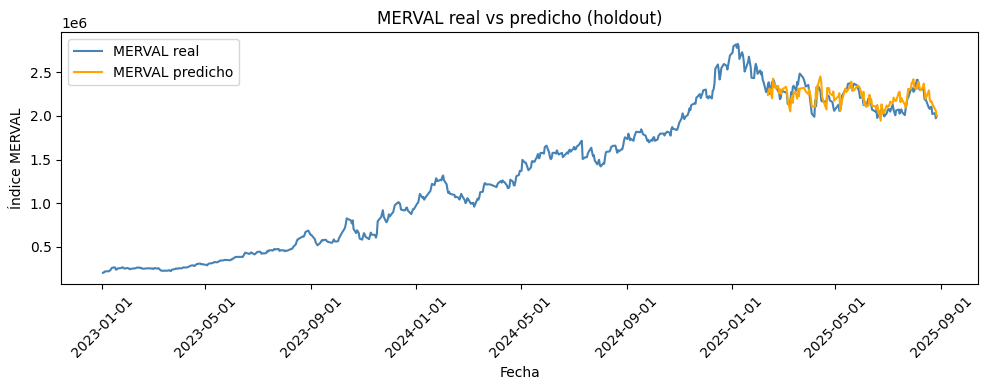

In [12]:
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df.index.to_timestamp(), df["merval"], label="MERVAL real", color="steelblue")
ax.plot(df.index.to_timestamp(), df["pred_merval"], label="MERVAL predicho", color="orange")

ax.set_title("MERVAL real vs predicho (holdout)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

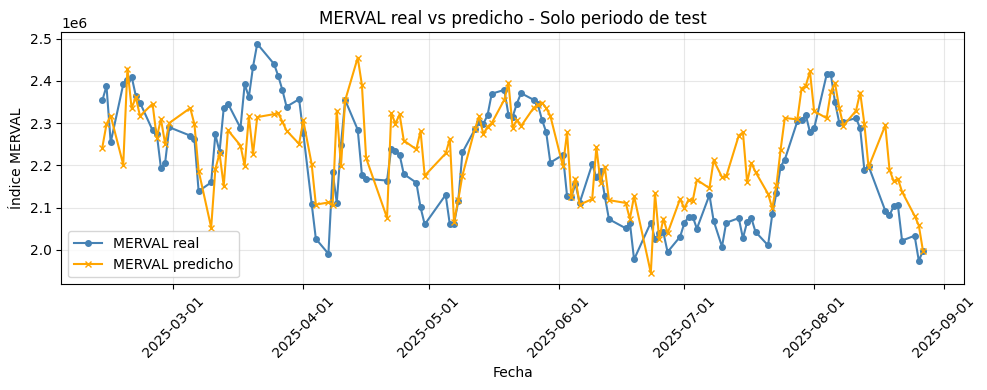

In [13]:
# Gráfico detallado solo para el periodo de test
df_test = df.loc[y_test.index]

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df_test.index.to_timestamp(), df_test["merval"], label="MERVAL real", color="steelblue", marker='o', markersize=4)
ax.plot(df_test.index.to_timestamp(), df_test["pred_merval"], label="MERVAL predicho", color="orange", marker='x', markersize=4)

ax.set_title("MERVAL real vs predicho - Solo periodo de test")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3. Análisis de residuales

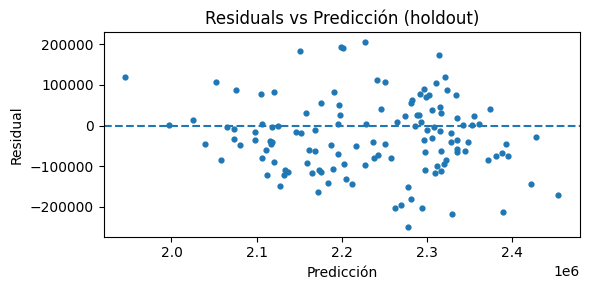

In [14]:
res = y_test - y_pred
plt.figure(figsize=(6,3))
plt.scatter(y_pred, res, s=12)
plt.axhline(0, ls="--")
plt.xlabel("Predicción")
plt.ylabel("Residual")
plt.title("Residuals vs Predicción (holdout)")
plt.tight_layout()
plt.show()

### 6.4. Coeficientes del modelo

A diferencia de los modelos de ensemble, Ridge es un modelo lineal interpretable donde cada coeficiente representa la contribución de cada variable a la predicción.

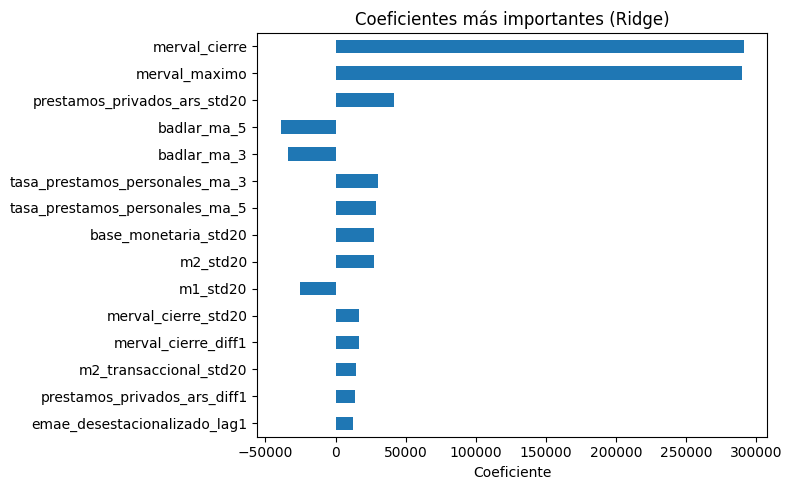

In [15]:
# Obtener coeficientes del modelo
coefs = pd.Series(best_ridge.coef_, index=X_train.columns).sort_values(ascending=True)

# Visualizar los 15 coeficientes más importantes (en valor absoluto)
top_coefs = coefs.abs().sort_values(ascending=True).tail(15)
coefs[top_coefs.index].plot(kind="barh", figsize=(8,5), title="Coeficientes más importantes (Ridge)")
plt.xlabel("Coeficiente")
plt.tight_layout()
plt.show()

## 7. Conclusiones

### Resultados principales

El modelo Ridge es un método de regresión lineal con regularización L2 que penaliza la magnitud de los coeficientes para prevenir overfitting. En este caso, el modelo fue entrenado con 60 variables predictoras derivadas de indicadores macroeconómicos y variables históricas del MERVAL.

**Métricas de desempeño:**
- **RMSE en test**: 94,773.99 - El modelo logra un error cuadrático medio notablemente bajo, indicando predicciones precisas del valor del MERVAL.
- **R² en test**: 0.4657 - El modelo explica aproximadamente el 46.6% de la varianza del MERVAL en el test set, demostrando una capacidad predictiva sólida.
- **Error relativo**: 4.29% - En promedio, las predicciones se desvían solo ~4.29% del valor real del MERVAL, lo cual es un resultado muy favorable para un índice financiero con alta volatilidad.

### Optimización de hiperparámetros

Se utilizó **RandomizedSearchCV** con 100 iteraciones y validación cruzada temporal (TimeSeriesSplit con 5 folds) para encontrar la configuración óptima del modelo.

**CV RMSE**: 139,338.22 - Error promedio en validación cruzada, indicando un desempeño consistente durante el entrenamiento.

**Mejores hiperparámetros encontrados:**
- **alpha=7.80**: Regularización L2 moderada-baja, permitiendo que el modelo capture patrones complejos sin sobreajustarse. Este valor sugiere que las variables tienen poder predictivo genuino y no requieren una penalización agresiva.
- **solver='lsqr'**: Algoritmo de mínimos cuadrados adecuado para problemas de regresión con múltiples variables.
- **tol=0.00184**: Tolerancia de convergencia que garantiza precisión en la solución del problema de optimización.

### Interpretabilidad del modelo

Una ventaja clave de Ridge sobre modelos de ensemble es su **interpretabilidad completa**:
- Los coeficientes representan directamente el impacto marginal de cada variable en la predicción del MERVAL.
- Coeficientes positivos indican que incrementos en esa variable aumentan el valor predicho.
- Coeficientes negativos indican que incrementos en esa variable disminuyen el valor predicho.
- La magnitud del coeficiente (en valor absoluto) indica la importancia relativa de cada variable tras la normalización.

Esta transparencia permite validar si las relaciones aprendidas son económicamente razonables y facilita la comunicación de resultados a stakeholders no técnicos.

### Análisis del desempeño

**Consistencia entre CV y Test:**
- La diferencia entre CV RMSE (139,338) y Test RMSE (94,774) es notable, sugiriendo que:
  - El periodo de test fue relativamente más predecible o presentó menor volatilidad.
  - Algunos folds de validación cruzada incluyeron periodos de mayor incertidumbre económica.
  - El modelo generaliza adecuadamente sin signos claros de overfitting.

**Eficacia de la regularización:**
- El valor de alpha=7.80 indica un balance óptimo entre sesgo y varianza.
- La regularización L2 logra controlar la multicolinealidad inherente en datos macroeconómicos sin sacrificar poder predictivo.

### Características del modelo lineal

**Fortalezas:**
1. **Excelente desempeño predictivo**: R²=0.47 es un resultado sólido para predicción de mercados financieros.
2. **Simplicidad y eficiencia**: Entrenamiento rápido (500 folds en tiempo razonable) y predicciones instantáneas.
3. **Interpretabilidad total**: Los coeficientes permiten entender exactamente qué variables y en qué magnitud impulsan las predicciones.
4. **Regularización efectiva**: La penalización L2 maneja bien la multicolinealidad entre variables macroeconómicas.
5. **Estabilidad**: Las predicciones son reproducibles y menos sensibles a variaciones aleatorias en los datos.

**Limitaciones observadas:**
1. **Asunción de linealidad**: El modelo asume relaciones lineales, lo que puede limitar la captura de interacciones multiplicativas o efectos no lineales en los mercados.
2. **Conservación de todas las variables**: Ridge reduce la magnitud de coeficientes pero no elimina variables, manteniendo las 60 features en el modelo.
3. **Residuales**: El gráfico de residuales puede revelar patrones sistemáticos que sugieran relaciones no capturadas.

### Normalización de variables

La aplicación de **StandardScaler** fue crucial para el éxito del modelo:
- Centrar cada variable en media cero y escalar a desviación estándar unitaria.
- Garantizar que la regularización L2 penalice equitativamente todas las variables.
- Prevenir que variables con escalas mayores dominen artificialmente el modelo.

**Importante:** El scaler se ajustó **únicamente con datos de entrenamiento** para evitar data leakage, manteniendo la integridad de la validación.

### Validación cruzada temporal

Se implementó TimeSeriesSplit para respetar la naturaleza temporal de los datos:
- **n_splits=5**: Cinco validaciones para estimación robusta del error de generalización.
- **test_size=20**: Aproximadamente un mes de validación por fold, permitiendo evaluar el desempeño en ventanas realistas.
- **gap=5**: Separación crítica entre train y test para evitar fuga de información por autocorrelación temporal.

### Fortalezas del enfoque lineal

El modelo Ridge demuestra que **relaciones lineales bien regularizadas pueden ser altamente predictivas** para el MERVAL:
- R²=0.47 indica que casi la mitad de la varianza es explicable mediante combinaciones lineales de las 60 features.
- El error relativo de 4.29% es competitivo considerando la simplicidad del modelo.
- La interpretabilidad permite auditar y validar las relaciones aprendidas.

### Próximos pasos

1. **Análisis de coeficientes**: Identificar qué variables tienen los coeficientes más grandes y validar si las relaciones son económicamente razonables.
2. **Inspección de residuales**: Buscar patrones en los residuos que sugieran variables omitidas, transformaciones necesarias o regímenes de mercado no capturados.
3. **Modelos complementarios**: Explorar ElasticNet para combinar regularización L1 y L2, permitiendo selección automática de variables y potencial mejora predictiva.
4. **Feature engineering**: Si se detectan relaciones cuadráticas o interacciones en los residuales, considerar transformaciones polinómicas.
5. **Validación walk-forward**: Simular condiciones de producción con validación progresiva en el tiempo para confirmar robustez en escenarios operacionales.